In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
xls = pd.ExcelFile('data/srcsc-2026-claims-business-interruption.xlsx')
xls.sheet_names  # List all sheet names

['freq', 'sev']

In [3]:
df_freq = pd.read_excel(xls, 'freq')
df_sev = pd.read_excel(xls, 'sev')
df_freq.head()

,policy_id,station_id,solar_system,production_load,energy_backup_score,supply_chain_index,avg_crew_exp,maintenance_freq,safety_compliance,exposure,claim_count
0,BI-000001,A4,Helionis Cluster,0.942,2.0,0.078,4.0,0.0,4.0,0.340,0.0
1,BI-000002,A8,Helionis Cluster,0.646,2.0,0.962,6.0,5.0,5.0,0.127,0.0
2,BI-000003,B1,Epsilon,0.004,4.0,0.746,5.0,2.0,4.0,0.487,0.0
3,BI-000004,G6,Helionis Cluster,0.215,2.0,0.717,14.0,6.0,5.0,0.464,0.0
4,BI-000005,G3,Epsilon,0.515,2.0,0.881,27.0,0.0,1.0,0.655,0.0


In [4]:
df_sev.head()

,claim_id,claim_seq,policy_id,station_id,solar_system,production_load,exposure,energy_backup_score,safety_compliance,claim_amount
0,BI-C-0000001,1.0,BI-000010,G3,Zeta,0.688,0.300,4.0,3.0,3397527.0
1,BI-C-0000002,2.0,BI-000010,G3,Zeta,0.688,0.300,4.0,3.0,720933.0
2,BI-C-0000003,1.0,BI-000015,G2,Helionis Cluster,0.414,0.570,3.0,5.0,961887.0
3,BI-C-0000004,1.0,BI-000028,A9,Zeta,0.355,0.334,3.0,1.0,522526.0
4,BI-C-0000005,1.0,BI-000056,B3,Epsilon,0.457,0.761,4.0,3.0,1152033.0


In [5]:
common_cols = set(df_freq.columns).intersection(set(df_sev.columns))
print("Common columns:")
print(common_cols)
uncommon_cols_freq = set(df_freq.columns) - common_cols
print("Uncommon columns in frequency dataset:")
print(uncommon_cols_freq)
uncommon_cols_sev = set(df_sev.columns) - common_cols
print("Uncommon columns in severity dataset:")
print(uncommon_cols_sev)

Common columns:
{'station_id', 'energy_backup_score', 'production_load', 'policy_id', 'solar_system', 'exposure', 'safety_compliance'}
Uncommon columns in frequency dataset:
{'supply_chain_index', 'claim_count', 'avg_crew_exp', 'maintenance_freq'}
Uncommon columns in severity dataset:
{'claim_seq', 'claim_id', 'claim_amount'}


In [6]:
def initial_cleaning(df):
    df = df.copy()
    print("Initial shape:", df.shape)
    print("Info:", df.info())

    cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns
    print("Categorical columns:", cat_cols)

    num_cols = df.select_dtypes(include=["number"]).columns
    print("Numerical columns:", num_cols)
    
    null_rows = df[df.isnull().any(axis=1)]
    null_pct = (len(null_rows) / len(df)) * 100
    print(f"Percentage of rows with null values: {null_pct:.2f}%")
    if null_pct < 5:
        df = df.dropna()
        print("Shape after dropping nulls:", df.shape)

    df["station_id"] = df["station_id"].str.extract(r"^([A-Za-z0-9\s]+)")
    df["solar_system"] = df["solar_system"].str.extract(r"^([A-Za-z\s]+)")
    df["station_id"].unique(), df["solar_system"].unique()


    # Ranges:
    # production_load 0-1,
    # energy_backup_score 1-5,
    # safety_compliance 1-5,
    # exposure 0-1,

    df_filtered = df[
        (df["production_load"] >= 0)
        & (df["production_load"] <= 1)
        & (df["energy_backup_score"] >= 1)
        & (df["energy_backup_score"] <= 5)
        & (df["safety_compliance"] >= 1)
        & (df["safety_compliance"] <= 5)
        & (df["exposure"] >= 0)
        & (df["exposure"] <= 1)
    ]

    # Ranges: Freq only:
    # supply_chain_index 0-1,
    # avg_crew_exp 1-30,
    # maintenance_freq 0-6,
    # claim_count 0-4
    if "supply_chain_index" in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["supply_chain_index"] >= 0)
            & (df_filtered["supply_chain_index"] <= 1)
        ]
        df_filtered["supply_chain_index"] = df_filtered["supply_chain_index"].astype(str)
    if "maintenance_freq" in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["maintenance_freq"] >= 0)
            & (df_filtered["maintenance_freq"] <= 6)
        ]
        df_filtered["maintenance_freq"] = df_filtered["maintenance_freq"].astype(str)
    if "avg_crew_exp" in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["avg_crew_exp"] >= 1) & (df_filtered["avg_crew_exp"] <= 30)
        ]
    if "claim_count" in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["claim_count"] >= 0) & (df_filtered["claim_count"] <= 4)
        ]
    if "claim_amount" in df_filtered.columns:
        df_filtered = df_filtered[df_filtered["claim_amount"] >= 0]

    print("Shape after range filtering:", df_filtered.shape)

    float_to_str_cols = ["safety_compliance", "energy_backup_score"]
    for col in float_to_str_cols:
        df_filtered[col] = df_filtered[col].astype(str)

    print("Filtered shape:", df_filtered.shape)
    return df_filtered

In [7]:
df_filtered_freq = initial_cleaning(df_freq)

Initial shape: (99923, 11)
<class 'pandas.DataFrame'>
RangeIndex: 99923 entries, 0 to 99922
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   policy_id            99794 non-null  str    
 1   station_id           99800 non-null  str    
 2   solar_system         99764 non-null  str    
 3   production_load      99814 non-null  float64
 4   energy_backup_score  99807 non-null  float64
 5   supply_chain_index   99827 non-null  float64
 6   avg_crew_exp         99809 non-null  float64
 7   maintenance_freq     99810 non-null  float64
 8   safety_compliance    99826 non-null  float64
 9   exposure             99822 non-null  float64
 10  claim_count          99819 non-null  float64
dtypes: float64(8), str(3)
memory usage: 8.4 MB
Info: None
Categorical columns: Index(['policy_id', 'station_id', 'solar_system'], dtype='str')
Numerical columns: Index(['production_load', 'energy_backup_score', 'supply_chain

In [8]:
df_filtered_sev = initial_cleaning(df_sev)

Initial shape: (10055, 10)
<class 'pandas.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             10040 non-null  str    
 1   claim_seq            10044 non-null  float64
 2   policy_id            10039 non-null  str    
 3   station_id           10032 non-null  str    
 4   solar_system         10044 non-null  str    
 5   production_load      10048 non-null  float64
 6   exposure             10042 non-null  float64
 7   energy_backup_score  10047 non-null  float64
 8   safety_compliance    10045 non-null  float64
 9   claim_amount         10047 non-null  float64
dtypes: float64(6), str(4)
memory usage: 785.7 KB
Info: None
Categorical columns: Index(['claim_id', 'policy_id', 'station_id', 'solar_system'], dtype='str')
Numerical columns: Index(['claim_seq', 'production_load', 'exposure', 'energy_backup_score',
       'safety_complianc

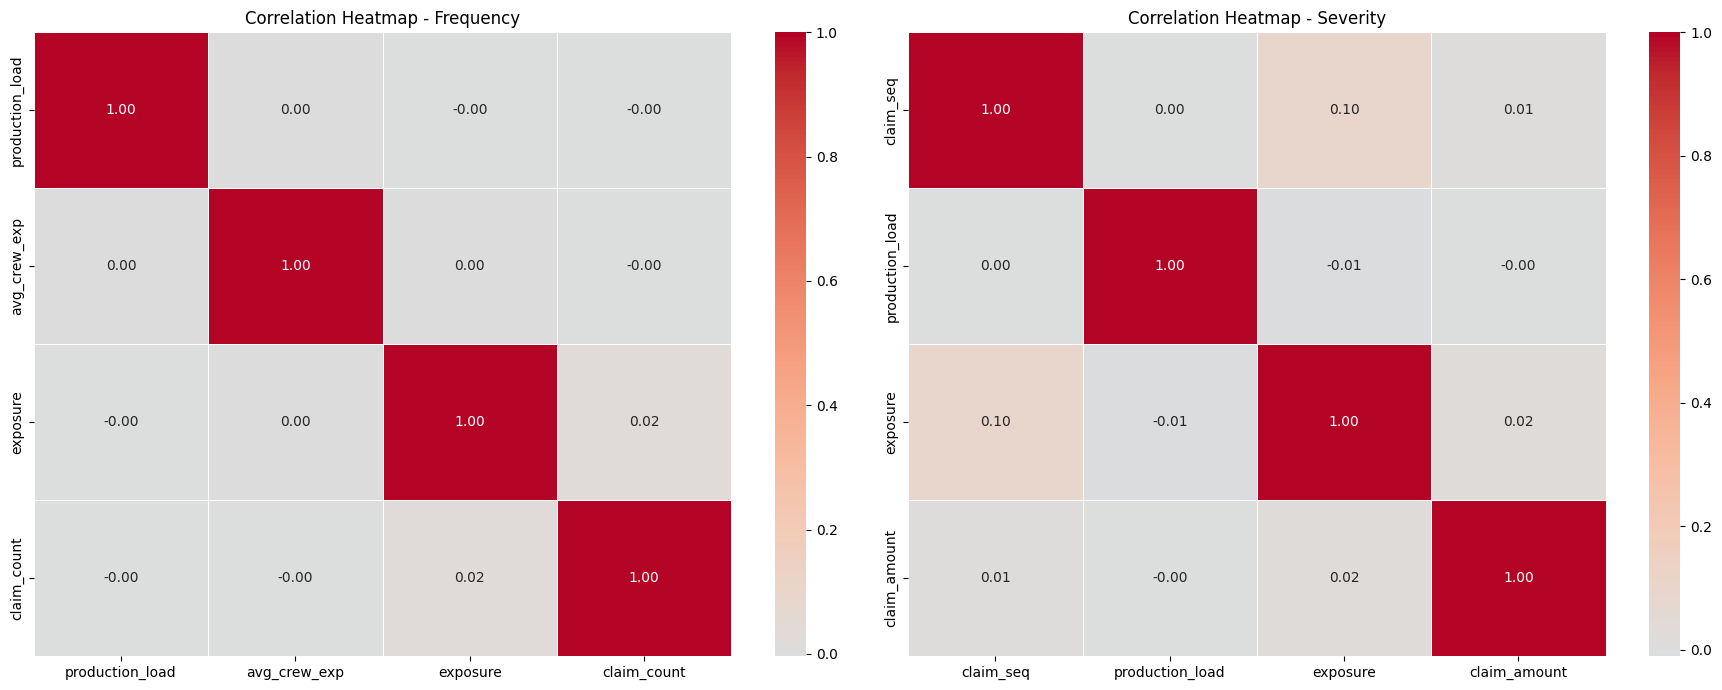

In [9]:
freq_corr = df_filtered_freq.select_dtypes(include="number").corr()
sev_corr = df_filtered_sev.select_dtypes(include="number").corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(freq_corr, ax=axes[0], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[0].set_title("Correlation Heatmap - Frequency")

sns.heatmap(sev_corr, ax=axes[1], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[1].set_title("Correlation Heatmap - Severity")

plt.tight_layout()

In [ ]:
df = df_filtered_freq.copy()
df.head()

In [ ]:
corr = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Create scatter plots for each pair of numerical columns using a random sample for each plot
sample_size = 2000  # adjust as needed

num_cols_list = df.select_dtypes(include=['number']).columns.tolist()
n_cols = len(num_cols_list)

fig, axes = plt.subplots(n_cols, n_cols, figsize=(20, 20))

# Create a color map for solar_system clusters
solar_system_colors = {'Helionis Cluster': 0, 'Epsilon': 1, 'Zeta': 2}

for i, col1 in enumerate(num_cols_list):
    for j, col2 in enumerate(num_cols_list):
        ax = axes[i, j]
        sample = df[[col1, col2, 'solar_system']].sample(n=min(sample_size, len(df)), random_state=42)
        if i == j:
            ax.hist(sample[col1], bins=30, alpha=0.7, color=['blue','yellow'])
            ax.set_ylabel(col1)
        else:
            sample_colors = [solar_system_colors[system] for system in sample['solar_system']]
            ax.scatter(sample[col2], sample[col1], alpha=0.3, s=10, c=sample_colors, cmap='tab10')
            ax.set_xlabel(col2)
            ax.set_ylabel(col1)
        if j == 0:
            ax.set_ylabel(col1, fontsize=10)
        if i == n_cols - 1:
            ax.set_xlabel(col2, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Create scatter plots for each pair of numerical columns using a random sample for each plot
sample_size = 2000  # adjust as needed

num_cols_list = df.select_dtypes(include=['number']).columns.tolist()
n_cols = len(num_cols_list)

fig, axes = plt.subplots(n_cols, n_cols, figsize=(20, 20))

# Use distinct colors for each solar system
solar_system_colors = {
    'Helionis Cluster': 'tab:blue',
    'Epsilon': 'tab:orange',
    'Zeta': 'tab:green'
}

for i, col1 in enumerate(num_cols_list):
    for j, col2 in enumerate(num_cols_list):
        ax = axes[i, j]
        sample = df[[col1, col2, 'solar_system']].sample(n=min(sample_size, len(df)), random_state=42)
        if i == j:
            for system, color in solar_system_colors.items():
                sns.kdeplot(
                    sample[sample['solar_system'] == system][col1],
                    ax=ax,
                    label=system if j == 0 else "",
                    fill=True,
                    common_norm=False,
                    alpha=0.5,
                    color=color
                )
            if j == 0:
                ax.legend()
            ax.set_ylabel(col1)
            ax.set_xlabel(col1)
        else:
            sample_colors = sample['solar_system'].map(solar_system_colors)
            ax.scatter(sample[col2], sample[col1], alpha=0.3, s=10, c=sample_colors)
            ax.set_xlabel(col2)
            ax.set_ylabel(col1)
        if j == 0:
            ax.set_ylabel(col1, fontsize=10)
        if i == n_cols - 1:
            ax.set_xlabel(col2, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Create hexbin plots for each pair of numerical columns using a random sample for each plot
sample_size = 2000  # adjust as needed

num_cols_list = df.select_dtypes(include=['number']).columns.tolist()
n_cols = len(num_cols_list)

fig, axes = plt.subplots(n_cols, n_cols, figsize=(20, 20))

for i, col1 in enumerate(num_cols_list):
    for j, col2 in enumerate(num_cols_list):
        ax = axes[i, j]
        sample = df[[col1, col2]].sample(n=min(sample_size, len(df)), random_state=42)
        if i == j:
            sns.kdeplot(sample[col1], ax=ax, fill=True, alpha=0.5)
            ax.set_ylabel(col1)
            ax.set_xlabel(col1)
        else:
            hb = ax.hexbin(sample[col2], sample[col1], gridsize=30, cmap='Blues', mincnt=1)
            ax.set_xlabel(col2)
            ax.set_ylabel(col1)
        if j == 0:
            ax.set_ylabel(col1, fontsize=10)
        if i == n_cols - 1:
            ax.set_xlabel(col2, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns
print("Categorical columns:", cat_cols)
num_cols = df.select_dtypes(include=["number"]).columns
print("Numerical columns:", num_cols)
# Create box plots for discrete variables against continuous variables
discrete_cols = ['energy_backup_score', 'supply_chain_index', 'maintenance_freq', 'safety_compliance']
continuous_cols = ['production_load', 'avg_crew_exp', 'exposure', 'claim_count']